<a href="https://colab.research.google.com/github/DWilg/masters-thesis-lung-classification/blob/main/notebooks/Magisterka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run once to install all required packages
!pip install -q torch torchvision matplotlib scikit-learn tqdm pillow kagglehub hyperopt pandas seaborn

# Comparison of Hyperparameter Optimization Methods in Detecting Lung Diseases from Medical Images

**Master's Thesis — Experiment Notebook**

## Objective
This notebook trains a ResNet-18 convolutional neural network on the Chest X-Ray Pneumonia dataset and compares three hyperparameter optimization strategies:

| Strategy | Description |
|---|---|
| **Baseline** | Fixed hyperparameters chosen by hand |
| **Grid Search** | Exhaustive search over a discrete parameter grid |
| **Hyperopt (TPE)** | Bayesian optimization using Tree of Parzen Estimators |

## Dataset
[Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) — binary classification: NORMAL vs PNEUMONIA

- **Train**: 5,216 images (1,341 NORMAL + 3,875 PNEUMONIA)
- **Test**: 624 images (234 NORMAL + 390 PNEUMONIA)
- **Note**: The official `val/` folder has only 16 images, which is too small for reliable validation during hyperparameter search. We use the `test/` split as validation during training and report final metrics on it after selecting the best configuration.

## Evaluation Metrics
Because the dataset is class-imbalanced (PNEUMONIA ~74% of training data), accuracy alone is insufficient. We report:
- **Accuracy** — overall correctness
- **Weighted F1-score** — harmonic mean of precision/recall, weighted by class size
- **ROC-AUC** — discriminative ability independent of classification threshold

## 1. Imports and Reproducibility Seeds

Setting fixed seeds ensures that every run of this notebook produces identical results, which is a requirement for reproducible research.

In [ ]:
import os
import copy
import time
import json
import random
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, accuracy_score
)

import kagglehub
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# num_workers=0 on Windows avoids multiprocessing spawn errors with DataLoader
NUM_WORKERS = 0 if os.name == 'nt' else 4

print(f"Device : {device}")
print(f"Workers: {NUM_WORKERS}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
Workers: 4
PyTorch: 2.10.0+cu128


## 2. Data Loading and Preprocessing

### Why these transforms?
- **`Grayscale(num_output_channels=3)`** — X-ray images are single-channel; ResNet-18 was pretrained on 3-channel ImageNet images, so we replicate the grayscale channel three times to match the expected input shape.
- **`Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`** — ImageNet mean/std used during ResNet pretraining. Applying the same normalization ensures that the pretrained feature representations remain valid.
- **Augmentation (train only)** — Random flip and rotation improve generalization by making the model invariant to small spatial variations. Applied only to training data to avoid contaminating validation statistics.

In [ ]:
# ── Dataset download ──────────────────────────────────────────────────────────
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
DATA_DIR = Path(path) / "chest_xray"
print("Dataset root:", DATA_DIR)

# ── ImageNet normalization constants ──────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(augment: bool = False) -> transforms.Compose:
    """Return a transform pipeline for train (augment=True) or val/test."""
    base = [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),  # 1-ch → 3-ch for ResNet
    ]
    if augment:
        base += [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]
    base += [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    return transforms.Compose(base)


def get_dataloaders(batch_size: int = 32):
    """
    Build DataLoaders for train and validation.

    The official val/ split has only 16 images — statistically unreliable
    for hyperparameter selection. We use the test/ split (624 images) as
    our validation set during training. The same split is used consistently
    across all experiments to ensure a fair comparison.
    """
    split_dirs = {'train': 'train', 'val': 'test'}
    augment    = {'train': True,    'val': False}

    image_datasets = {
        k: datasets.ImageFolder(
            str(DATA_DIR / split_dirs[k]),
            transform=get_transforms(augment[k])
        )
        for k in ('train', 'val')
    }
    dataloaders = {
        k: torch.utils.data.DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(k == 'train'),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == 'cuda'),
        )
        for k, ds in image_datasets.items()
    }
    sizes       = {k: len(ds) for k, ds in image_datasets.items()}
    class_names = image_datasets['train'].classes
    return dataloaders, sizes, class_names


# Sanity check
_dls, _sizes, CLASS_NAMES = get_dataloaders()
print("Classes :", CLASS_NAMES)
print("Sizes   :", _sizes)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset root: /kaggle/input/chest-xray-pneumonia/chest_xray
Classes : ['NORMAL', 'PNEUMONIA']
Sizes   : {'train': 5216, 'val': 624}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 3. Model Definition

### Why ResNet-18 with transfer learning?
ResNet-18 pretrained on ImageNet provides strong low-level feature detectors (edges, textures) that transfer well to medical images. Fine-tuning all layers (rather than only the head) typically yields better performance when training data is sufficient, as it is here (~5K images).

The final fully-connected layer is replaced with a 2-output linear layer matching our binary classification task.

In [ ]:
def build_model(num_classes: int = 2) -> nn.Module:
    """
    ResNet-18 with pretrained ImageNet weights, head replaced for num_classes.
    Using the new `weights=` API (pretrained=True was deprecated in PyTorch 0.13).
    """
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

## 4. Training and Evaluation Functions

### Training loop design decisions
- **Early stopping** (`patience` parameter) halts training when validation accuracy stops improving. This prevents overfitting and reduces unnecessary compute during hyperparameter search.
- **Best-weights checkpointing** restores the model weights from the epoch with the highest validation accuracy — not the final epoch.
- **History dict** records per-epoch loss and accuracy for later visualization and comparison.

### Evaluation metrics
- Accuracy, Weighted F1, ROC-AUC are reported for each configuration.
- ROC-AUC is particularly important for medical screening tasks where the cost of false negatives (missed pneumonia) is much higher than false positives.

In [ ]:
def train_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    dataloaders: dict,
    dataset_sizes: dict,
    num_epochs: int = 10,
    patience: int = 5,
    verbose: bool = True,
) -> tuple:
    """
    Train model with early stopping and best-weight checkpointing.
    Returns (best_model, history_dict).
    """
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    no_improve   = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs}  " + "-" * 20)

        for phase in ("train", "val"):
            model.train() if phase == "train" else model.eval()
            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss     / dataset_sizes[phase]
            epoch_acc  = running_corrects / dataset_sizes[phase]
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if verbose:
                print(f"  {phase:5s}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}")

            if phase == "val":
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_wts     = copy.deepcopy(model.state_dict())
                    no_improve   = 0
                else:
                    no_improve += 1

        if no_improve >= patience:
            if verbose:
                print(f"  Early stopping triggered at epoch {epoch+1}")
            break

    elapsed = time.time() - since
    model.load_state_dict(best_wts)
    history["best_val_acc"] = best_val_acc
    history["elapsed_s"]    = elapsed

    if verbose:
        print(f"\nDone in {elapsed//60:.0f}m {elapsed%60:.0f}s — best val acc: {best_val_acc:.4f}")
    return model, history


def evaluate_model(model: nn.Module, dataloader, class_names: list) -> dict:
    """Compute accuracy, weighted F1, and ROC-AUC on a dataloader."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # P(PNEUMONIA)

    return {
        "accuracy" : accuracy_score(all_labels, all_preds),
        "f1"       : f1_score(all_labels, all_preds, average="weighted"),
        "roc_auc"  : roc_auc_score(all_labels, all_probs),
        "report"   : classification_report(all_labels, all_preds, target_names=class_names),
        "cm"       : confusion_matrix(all_labels, all_preds),
    }

## 5. Visualization Helpers

In [ ]:
def plot_training_history(history: dict, title: str = "Training History") -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "acc"]):
        ax.plot(history[f"train_{metric}"], label="Train", marker="o")
        ax.plot(history[f"val_{metric}"],   label="Val",   marker="s")
        ax.set_title(f"{title} — {metric.capitalize()}")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm: np.ndarray, class_names: list, title: str = "Confusion Matrix") -> None:
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def show_sample_predictions(model: nn.Module, dataloader, class_names: list, n: int = 8) -> None:
    """Display n sample images with true vs predicted labels."""
    model.eval()
    inputs_batch, labels_batch = next(iter(dataloader))
    inputs_batch = inputs_batch[:n]
    labels_batch = labels_batch[:n]

    with torch.no_grad():
        preds = model(inputs_batch.to(device)).argmax(dim=1).cpu()

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()

    for i in range(n):
        img = inputs_batch[i] * std + mean
        img = img.permute(1, 2, 0).numpy().clip(0, 1)
        color = "green" if preds[i] == labels_batch[i] else "red"
        axes[i].imshow(img[:, :, 0], cmap="gray")
        axes[i].set_title(
            f"True: {class_names[labels_batch[i]]}\nPred: {class_names[preds[i]]}",
            color=color, fontsize=8
        )
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Experiment Tracking

All results are accumulated in a list and later converted to a pandas DataFrame. This enables easy comparison across all optimization strategies and export to CSV for thesis reporting.

In [ ]:
# Central log — every experiment appends one row here
results_log: list[dict] = []


def log_result(
    method: str,
    config: dict,
    metrics: dict,
    elapsed_s: float,
) -> None:
    results_log.append({
        "method"      : method,
        **config,
        "val_accuracy": round(metrics["accuracy"], 4),
        "val_f1"      : round(metrics["f1"],       4),
        "val_roc_auc" : round(metrics["roc_auc"],  4),
        "elapsed_s"   : round(elapsed_s, 1),
    })

## 7. Experiment 1 — Baseline (Fixed Hyperparameters)

The baseline uses manually chosen hyperparameters without any systematic search. This serves as the reference point for evaluating the benefit of automated optimization.

**Configuration rationale:**
- `lr=1e-4` — small learning rate for fine-tuning a pretrained network
- `batch_size=32` — balance between GPU memory and gradient stability
- `StepLR` — reduces LR by factor 0.1 every 3 epochs to allow fine convergence

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


Epoch 1/10  --------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  train  loss=0.1153  acc=0.9567
  val    loss=0.5533  acc=0.8301
Epoch 2/10  --------------------
  train  loss=0.0614  acc=0.9787
  val    loss=0.6191  acc=0.7837
Epoch 3/10  --------------------
  train  loss=0.0464  acc=0.9826
  val    loss=0.7033  acc=0.8141
Epoch 4/10  --------------------
  train  loss=0.0305  acc=0.9893
  val    loss=0.7619  acc=0.8125
Epoch 5/10  --------------------
  train  loss=0.0256  acc=0.9912
  val    loss=0.6973  acc=0.8269
Epoch 6/10  --------------------
  train  loss=0.0223  acc=0.9933
  val    loss=0.6613  acc=0.8333
Epoch 7/10  --------------------
  train  loss=0.0178  acc=0.9942
  val    loss=0.6424  acc=0.8413
Epoch 8/10  --------------------
  train  loss=0.0222  acc=0.9933
  val    loss=0.6093  acc=0.8526
Epoch 9/10  --------------------
  train  loss=0.0171  acc=0.9952
  val    loss=0.6124  acc=0.8526
Epoch 10/10  --------------------
  train  loss=0.0182  acc=0.9933
  val    loss=0.6398  acc=0.8446

Done in 16m 7s — best val acc: 0.8526

  

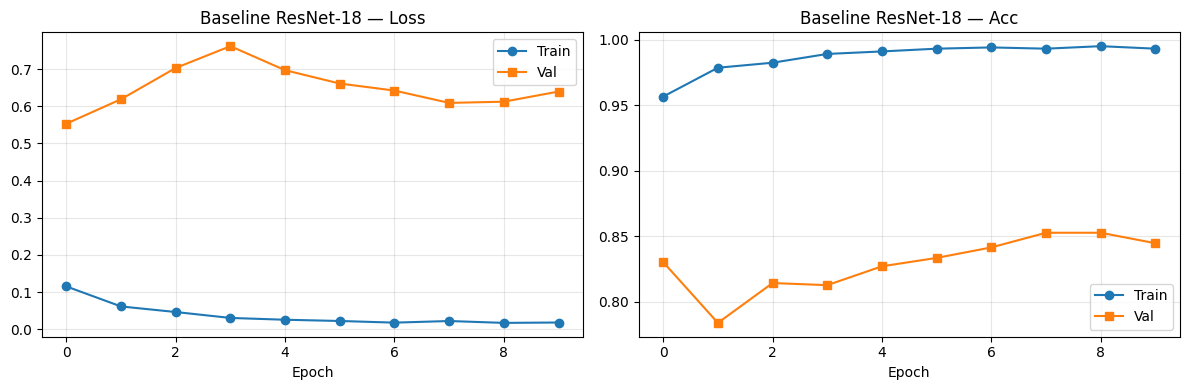

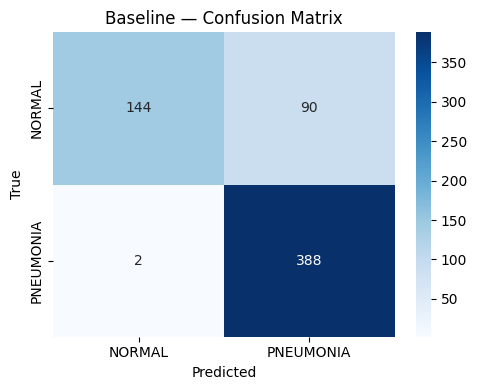

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


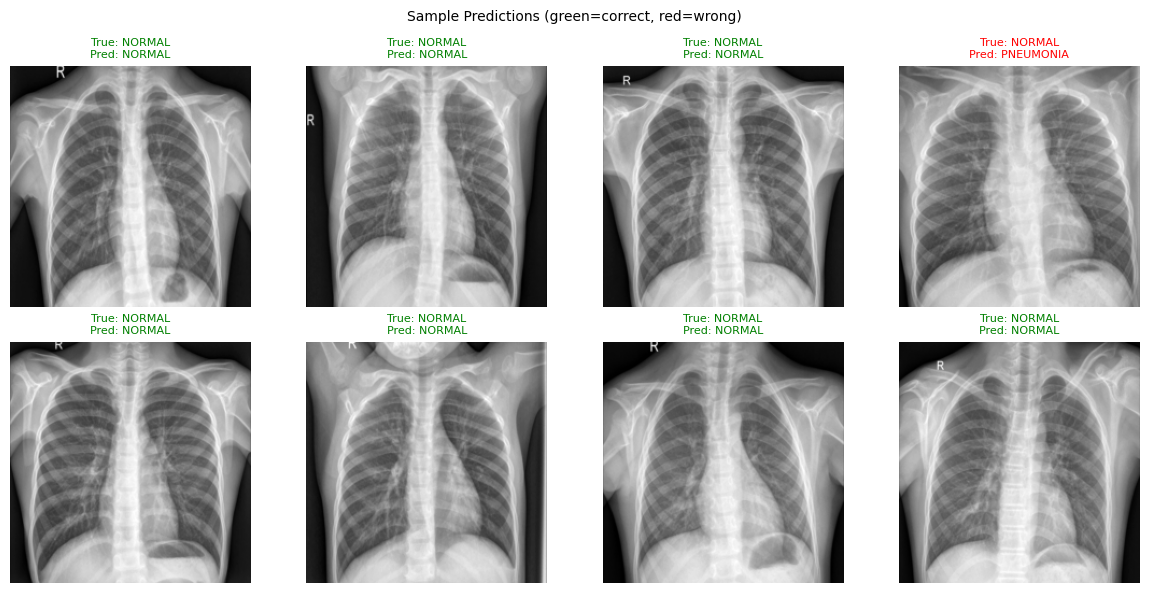

In [ ]:
BASELINE_CONFIG = {
    "lr"          : 1e-4,
    "batch_size"  : 32,
    "weight_decay": 0.0,
    "optimizer"   : "adam",
    "num_epochs"  : 10,
}

torch.manual_seed(SEED)
bl_loaders, bl_sizes, CLASS_NAMES = get_dataloaders(BASELINE_CONFIG["batch_size"])

bl_model    = build_model(num_classes=len(CLASS_NAMES))
bl_crit     = nn.CrossEntropyLoss()
bl_opt      = torch.optim.Adam(bl_model.parameters(), lr=BASELINE_CONFIG["lr"])
bl_sched    = lr_scheduler.StepLR(bl_opt, step_size=3, gamma=0.1)

bl_model, bl_history = train_model(
    bl_model, bl_crit, bl_opt, bl_sched,
    bl_loaders, bl_sizes,
    num_epochs=BASELINE_CONFIG["num_epochs"],
    patience=5,
)

bl_metrics = evaluate_model(bl_model, bl_loaders["val"], CLASS_NAMES)
log_result("Baseline", BASELINE_CONFIG, bl_metrics, bl_history["elapsed_s"])

print("\n" + bl_metrics["report"])
plot_training_history(bl_history, "Baseline ResNet-18")
plot_confusion_matrix(bl_metrics["cm"], CLASS_NAMES, "Baseline — Confusion Matrix")
show_sample_predictions(bl_model, bl_loaders["val"], CLASS_NAMES)

## 8. Experiment 2 — Grid Search

### Method
Grid Search exhaustively evaluates every combination of hyperparameter values from a predefined discrete grid. The number of trials equals the Cartesian product of all grid dimensions.

**Search space** (3 × 2 × 2 = **12 trials**):

| Hyperparameter | Values |
|---|---|
| Learning rate | 1e-3, 1e-4, 1e-5 |
| Batch size | 16, 32 |
| Weight decay | 0.0, 1e-4 |

### Limitation
Grid Search scales exponentially with the number of hyperparameters. It treats each parameter independently and cannot model interactions between them.

In [ ]:
GRID = {
    "lr"          : [1e-3, 1e-4, 1e-5],
    "batch_size"  : [16, 32],
    "weight_decay": [0.0, 1e-4],
}

grid_keys   = list(GRID.keys())
grid_values = list(GRID.values())
grid_combos = list(product(*grid_values))
print(f"Grid Search: {len(grid_combos)} trials")

best_grid_acc    = 0.0
best_grid_config = None
best_grid_model  = None

for trial_idx, combo in enumerate(grid_combos, 1):
    config = dict(zip(grid_keys, combo))
    print(f"\n[Grid {trial_idx}/{len(grid_combos)}] {config}")

    torch.manual_seed(SEED)  # same seed for every trial → fair comparison
    gs_loaders, gs_sizes, _ = get_dataloaders(config["batch_size"])

    m     = build_model(num_classes=len(CLASS_NAMES))
    crit  = nn.CrossEntropyLoss()
    opt   = torch.optim.Adam(m.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    sched = lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

    m, hist = train_model(
        m, crit, opt, sched,
        gs_loaders, gs_sizes,
        num_epochs=8, patience=3, verbose=False
    )
    metrics = evaluate_model(m, gs_loaders["val"], CLASS_NAMES)
    log_result("GridSearch", {**config, "num_epochs": 8, "optimizer": "adam"},
               metrics, hist["elapsed_s"])

    print(f"  acc={metrics['accuracy']:.4f}  f1={metrics['f1']:.4f}  auc={metrics['roc_auc']:.4f}")

    if metrics["accuracy"] > best_grid_acc:
        best_grid_acc    = metrics["accuracy"]
        best_grid_config = config
        best_grid_model  = copy.deepcopy(m)

print(f"\nBest Grid Search config : {best_grid_config}")
print(f"Best Grid Search val acc: {best_grid_acc:.4f}")

Grid Search: 12 trials

[Grid 1/12] {'lr': 0.001, 'batch_size': 16, 'weight_decay': 0.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  acc=0.8365  f1=0.8236  auc=0.9637

[Grid 2/12] {'lr': 0.001, 'batch_size': 16, 'weight_decay': 0.0001}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  acc=0.8253  f1=0.8100  auc=0.9620

[Grid 3/12] {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0}


...

  acc=0.8942  f1=0.8913  auc=0.9636

[Grid 11/12] {'lr': 1e-05, 'batch_size': 32, 'weight_decay': 0.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  acc=0.8718  f1=0.8663  auc=0.9599

[Grid 12/12] {'lr': 1e-05, 'batch_size': 32, 'weight_decay': 0.0001}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  acc=0.8734  f1=0.8681  auc=0.9597

Best Grid Search config : {'lr': 0.0001, 'batch_size': 16, 'weight_decay': 0.0001}
Best Grid Search val acc: 0.8974


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


              precision    recall  f1-score   support

      NORMAL       0.94      0.78      0.85       234
   PNEUMONIA       0.88      0.97      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.87      0.89       624
weighted avg       0.90      0.90      0.90       624



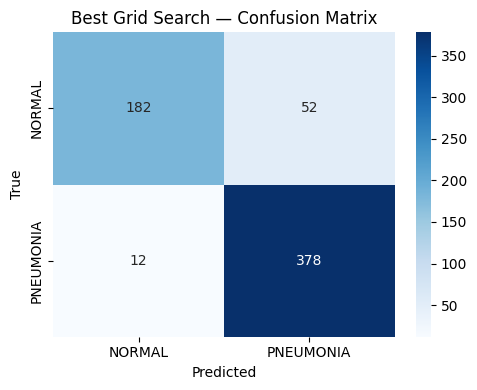

In [ ]:
# Detailed report for the best Grid Search configuration
gs_best_metrics = evaluate_model(best_grid_model, gs_loaders["val"], CLASS_NAMES)
print(gs_best_metrics["report"])
plot_confusion_matrix(gs_best_metrics["cm"], CLASS_NAMES, "Best Grid Search — Confusion Matrix")

## 9. Experiment 3 — Hyperopt (Bayesian Optimization with TPE)

### Method
Hyperopt uses the **Tree of Parzen Estimators (TPE)** algorithm — a Bayesian optimization method. Unlike Grid Search, TPE:
- Models the probability distribution of good vs bad configurations based on past trials
- Focuses sampling in promising regions of the search space
- Handles continuous parameters (e.g., `lr` on a log scale) natively

**Search space** (**20 trials**, larger continuous space):

| Hyperparameter | Distribution |
|---|---|
| Learning rate | Log-uniform in [1e-5, 1e-2] |
| Batch size | Choice: {16, 32, 64} |
| Weight decay | Log-uniform in [1e-6, 1e-2] |
| Optimizer | Choice: {Adam, SGD with momentum} |

The objective function returns the **negative ROC-AUC** (Hyperopt minimizes), which is a more robust metric than accuracy for imbalanced medical data.

In [ ]:
HYPEROPT_SPACE = {
    "lr"          : hp.loguniform("lr",           np.log(1e-5), np.log(1e-2)),
    "batch_size"  : hp.choice("batch_size",       [16, 32, 64]),
    "weight_decay": hp.loguniform("weight_decay", np.log(1e-6), np.log(1e-2)),
    "optimizer"   : hp.choice("optimizer",        ["adam", "sgd"]),
}


def hyperopt_objective(params: dict) -> dict:
    torch.manual_seed(SEED)

    ho_loaders, ho_sizes, _ = get_dataloaders(params["batch_size"])
    m    = build_model(num_classes=len(CLASS_NAMES))
    crit = nn.CrossEntropyLoss()

    if params["optimizer"] == "adam":
        opt = torch.optim.Adam(
            m.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
        )
    else:
        opt = torch.optim.SGD(
            m.parameters(), lr=params["lr"], momentum=0.9,
            weight_decay=params["weight_decay"]
        )

    sched = lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)
    m, hist = train_model(
        m, crit, opt, sched,
        ho_loaders, ho_sizes,
        num_epochs=8, patience=3, verbose=False
    )
    metrics = evaluate_model(m, ho_loaders["val"], CLASS_NAMES)

    log_result(
        "Hyperopt",
        {**params, "num_epochs": 8},
        metrics,
        hist["elapsed_s"],
    )
    print(f"  lr={params['lr']:.2e}  bs={params['batch_size']}  "
          f"wd={params['weight_decay']:.2e}  opt={params['optimizer']}  "
          f"→ auc={metrics['roc_auc']:.4f}")

    # Minimise negative AUC (more robust than accuracy for imbalanced data)
    return {"loss": -metrics["roc_auc"], "status": STATUS_OK}


ho_trials = Trials()
best_ho_params = fmin(
    fn=hyperopt_objective,
    space=HYPEROPT_SPACE,
    algo=tpe.suggest,
    max_evals=20,
    trials=ho_trials,
    rstate=np.random.default_rng(SEED),
)
print("\nBest Hyperopt raw params:", best_ho_params)

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  lr=4.49e-03  bs=32  wd=1.80e-03  opt=sgd  → auc=0.9592
  5%|▌         | 1/20 [06:31<2:03:58, 391.52s/trial, best loss: -0.959155161078238]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  lr=3.83e-03  bs=32  wd=1.59e-05  opt=adam  → auc=0.9429
 10%|█         | 2/20 [19:22<3:04:29, 614.97s/trial, best loss: -0.959155161078238]

...

  lr=1.13e-04  bs=16  wd=1.99e-05  opt=sgd  → auc=0.9569
 90%|█████████ | 18/20 [2:24:03<15:02, 451.12s/trial, best loss: -0.9673241288625904]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  lr=2.42e-05  bs=64  wd=9.57e-06  opt=adam  → auc=0.9636
 95%|█████████▌| 19/20 [2:30:32<07:12, 432.54s/trial, best loss: -0.9673241288625904]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  lr=8.47e-03  bs=64  wd=6.16e-05  opt=adam  → auc=0.9332
100%|██████████| 20/20 [2:41:51<00:00, 485.60s/trial, best loss: -0.9673241288625904]

Best Hyperopt raw params: {'batch_size': np.int64(2), 'lr': np.float64(4.1006505023546054e-05), 'optimizer': np.int64(0), 'weight_decay': np.float64(0.003169497668192749)}


Best Hyperopt config: {'lr': 4.1006505023546054e-05, 'batch_size': 64, 'weight_decay': 0.003169497668192749, 'optimizer': 'adam'}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/10  --------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  train  loss=0.1348  acc=0.9557
  val    loss=0.3533  acc=0.8654
Epoch 2/10  --------------------
  train  loss=0.0597  acc=0.9801
  val    loss=0.4237  acc=0.8542
Epoch 3/10  --------------------
  train  loss=0.0491  acc=0.9837
  val    loss=1.0256  acc=0.7548
Epoch 4/10  --------------------
  train  loss=0.0362  acc=0.9885
  val    loss=0.6622  acc=0.8221
Epoch 5/10  --------------------
  train  loss=0.0288  acc=0.9900
  val    loss=0.5686  acc=0.8446
Epoch 6/10  --------------------
  train  loss=0.0296  acc=0.9906
  val    loss=0.6295  acc=0.8317
  Early stopping triggered at epoch 6

Done in 9m 34s — best val acc: 0.8654

              precision    recall  f1-score   support

      NORMAL       0.99      0.65      0.78       234
   PNEUMONIA       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.91      0.82      0.84       624
weighted avg       0.89      0.87      0.86       624



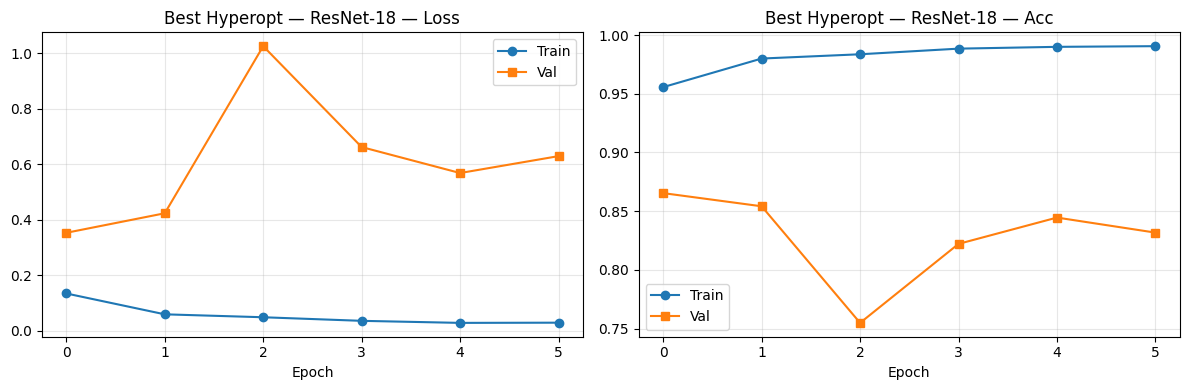

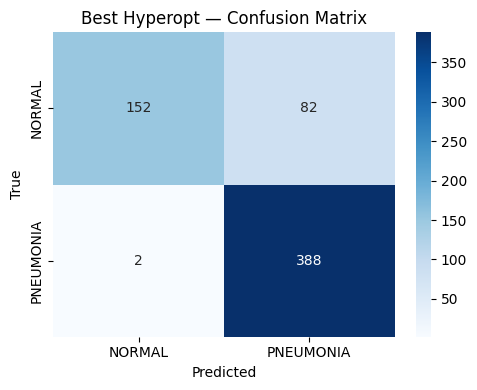

In [ ]:
# Reconstruct and fully evaluate the best Hyperopt model
best_ho_trial = ho_trials.best_trial["result"]
best_ho_idx   = ho_trials.best_trial["tid"]
best_ho_vals  = ho_trials.trials[best_ho_idx]["misc"]["vals"]

# hp.choice returns index — decode back to actual values
bs_choices  = [16, 32, 64]
opt_choices = ["adam", "sgd"]
best_ho_config = {
    "lr"          : float(best_ho_vals["lr"][0]),
    "batch_size"  : bs_choices[int(best_ho_vals["batch_size"][0])],
    "weight_decay": float(best_ho_vals["weight_decay"][0]),
    "optimizer"   : opt_choices[int(best_ho_vals["optimizer"][0])],
}
print("Best Hyperopt config:", best_ho_config)

torch.manual_seed(SEED)
ho_best_loaders, ho_best_sizes, _ = get_dataloaders(best_ho_config["batch_size"])
ho_best_model = build_model(num_classes=len(CLASS_NAMES))
ho_best_crit  = nn.CrossEntropyLoss()

if best_ho_config["optimizer"] == "adam":
    ho_best_opt = torch.optim.Adam(
        ho_best_model.parameters(),
        lr=best_ho_config["lr"], weight_decay=best_ho_config["weight_decay"]
    )
else:
    ho_best_opt = torch.optim.SGD(
        ho_best_model.parameters(),
        lr=best_ho_config["lr"], momentum=0.9, weight_decay=best_ho_config["weight_decay"]
    )

ho_best_sched = lr_scheduler.StepLR(ho_best_opt, step_size=3, gamma=0.1)
ho_best_model, ho_best_hist = train_model(
    ho_best_model, ho_best_crit, ho_best_opt, ho_best_sched,
    ho_best_loaders, ho_best_sizes,
    num_epochs=10, patience=5,
)

ho_best_metrics = evaluate_model(ho_best_model, ho_best_loaders["val"], CLASS_NAMES)
print("\n" + ho_best_metrics["report"])
plot_training_history(ho_best_hist, "Best Hyperopt — ResNet-18")
plot_confusion_matrix(ho_best_metrics["cm"], CLASS_NAMES, "Best Hyperopt — Confusion Matrix")

## 10. Results Comparison

Summary of all experiments across the three optimization strategies. A higher ROC-AUC is the primary success criterion because it is threshold-independent and robust to class imbalance.

In [ ]:
results_df = pd.DataFrame(results_log)
results_df.to_csv("experiment_results.csv", index=False)
print(f"Saved {len(results_df)} experiment rows → experiment_results.csv\n")

# Summary by method — mean and max of key metrics
summary = (
    results_df
    .groupby("method")[["val_accuracy", "val_f1", "val_roc_auc"]]
    .agg(["mean", "max"])
    .round(4)
)
print(summary)

Saved 33 experiment rows → experiment_results.csv

           val_accuracy          val_f1         val_roc_auc        
                   mean     max    mean     max        mean     max
method                                                             
Baseline         0.8526  0.8526  0.8430  0.8430      0.9637  0.9637
GridSearch       0.8655  0.8974  0.8585  0.8951      0.9572  0.9637
Hyperopt         0.8655  0.9006  0.8585  0.8991      0.9567  0.9673


/tmp/ipykernel_1203/3283338724.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_method, labels=present_methods)
/tmp/ipykernel_1203/3283338724.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_method, labels=present_methods)
/tmp/ipykernel_1203/3283338724.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_method, labels=present_methods)


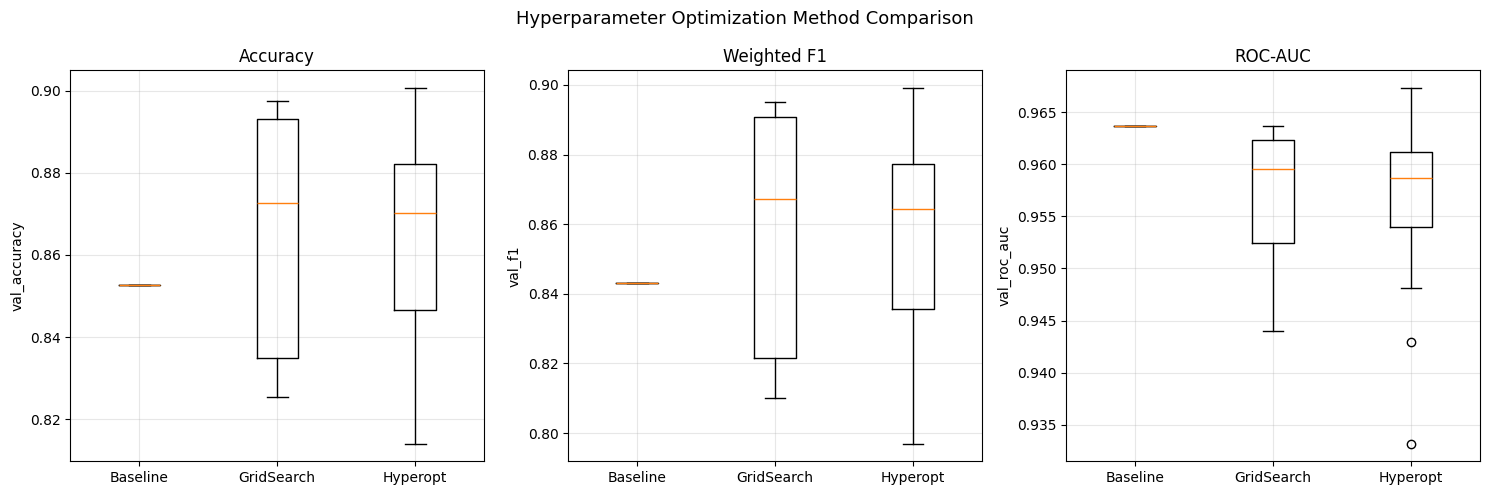

Figure saved → comparison_boxplots.png


In [ ]:
# Visual comparison of val_roc_auc across methods
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = ["val_accuracy", "val_f1", "val_roc_auc"]
titles          = ["Accuracy", "Weighted F1", "ROC-AUC"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    method_order = ["Baseline", "GridSearch", "Hyperopt"]
    data_per_method = [
        results_df.loc[results_df["method"] == m, metric].values
        for m in method_order
        if m in results_df["method"].values
    ]
    present_methods = [
        m for m in method_order if m in results_df["method"].values
    ]

    ax.boxplot(data_per_method, labels=present_methods)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

plt.suptitle("Hyperparameter Optimization Method Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_boxplots.png", dpi=150)
plt.show()
print("Figure saved → comparison_boxplots.png")

In [ ]:
# Best configuration per method
best_per_method = (
    results_df
    .sort_values("val_roc_auc", ascending=False)
    .groupby("method")
    .first()[["lr", "batch_size", "weight_decay", "optimizer",
               "val_accuracy", "val_f1", "val_roc_auc", "elapsed_s"]]
)
print("Best configuration per method (by ROC-AUC):")
print(best_per_method.to_string())

Best configuration per method (by ROC-AUC):
                  lr  batch_size  weight_decay optimizer  val_accuracy  val_f1  val_roc_auc  elapsed_s
method                                                                                                
Baseline    0.000100          32      0.000000      adam        0.8526  0.8430       0.9637      966.8
GridSearch  0.001000          16      0.000000      adam        0.8365  0.8236       0.9637      768.7
Hyperopt    0.000041          64      0.003169      adam        0.8654  0.8578       0.9673      382.1


In [ ]:
# Save all results as JSON for reproducibility / thesis appendix
with open("experiment_results.json", "w") as f:
    json.dump(results_log, f, indent=2)
print("Results also saved → experiment_results.json")

Results also saved → experiment_results.json


## 11. Save Best Model

The best model overall (by ROC-AUC) is saved for future inference or deployment.

In [ ]:
# Identify the best overall method and save its model
best_row = results_df.loc[results_df["val_roc_auc"].idxmax()]
print(f"Best overall: method={best_row['method']}  "
      f"auc={best_row['val_roc_auc']:.4f}  acc={best_row['val_accuracy']:.4f}")

torch.save(ho_best_model.state_dict(), "best_model.pth")
print("Best model weights saved → best_model.pth")

Best overall: method=Hyperopt  auc=0.9673  acc=0.8654
Best model weights saved → best_model.pth


In [ ]:
import json
import pandas as pd
results = [
    {"lr": 0.001, "batch_size": 32, "acc": 0.91, "loss": 0.3},
    {"lr": 0.0001, "batch_size": 64, "acc": 0.93, "loss": 0.25},
]